In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from config import MODELS_DIR, PROCESSED_DATA_DIR, RAW_DATA_DIR

In [2]:
sns.set_theme(style="whitegrid", context="notebook")

## Load Data And Model

In [3]:
pokemon_features = pd.read_parquet(PROCESSED_DATA_DIR / "pokemon_data_features.parquet")
pokemon_raw = pd.read_csv(RAW_DATA_DIR / "pokedex.csv")

In [4]:
y = pokemon_features["total_points"]
X = pokemon_features.drop(columns=["total_points"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

metadata_cols = ["name", "status", "type_1", "type_2", "generation", "height_m", "weight_kg"]
metadata_test = pokemon_raw.loc[X_test.index, metadata_cols].copy()

In [5]:
model = joblib.load(MODELS_DIR / "xg_boost_initial.joblib")

## Overall Test Performance

In [6]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost R^2: {r2:.3f}")

XGBoost RMSE: 60.49
XGBoost MAE: 45.69
XGBoost R^2: 0.761


## Prediction Table

In [7]:
results = metadata_test.copy()
results["true_total_points"] = y_test.values
results["pred_total_points"] = y_pred
results["residual"] = results["true_total_points"] - results["pred_total_points"]
results["abs_error"] = results["residual"].abs()
results.head()

,name,status,type_1,type_2,generation,height_m,weight_kg,true_total_points,pred_total_points,residual,abs_error
773,Diggersby,Normal,Normal,Ground,6,1.0,42.4,423,430.907562,-7.907562,7.907562
280,Houndoom,Normal,Dark,Fire,2,1.4,35.0,500,491.540314,8.459686,8.459686
629,Mega Audino,Normal,Normal,Fairy,5,1.5,32.0,545,521.922729,23.077271,23.077271
318,Mightyena,Normal,Dark,NaN,3,1.0,37.0,420,444.152435,-24.152435,24.152435
1008,Pincurchin,Normal,Electric,NaN,8,0.3,1.0,435,338.508026,96.491974,96.491974


## Prediction Diagnostics

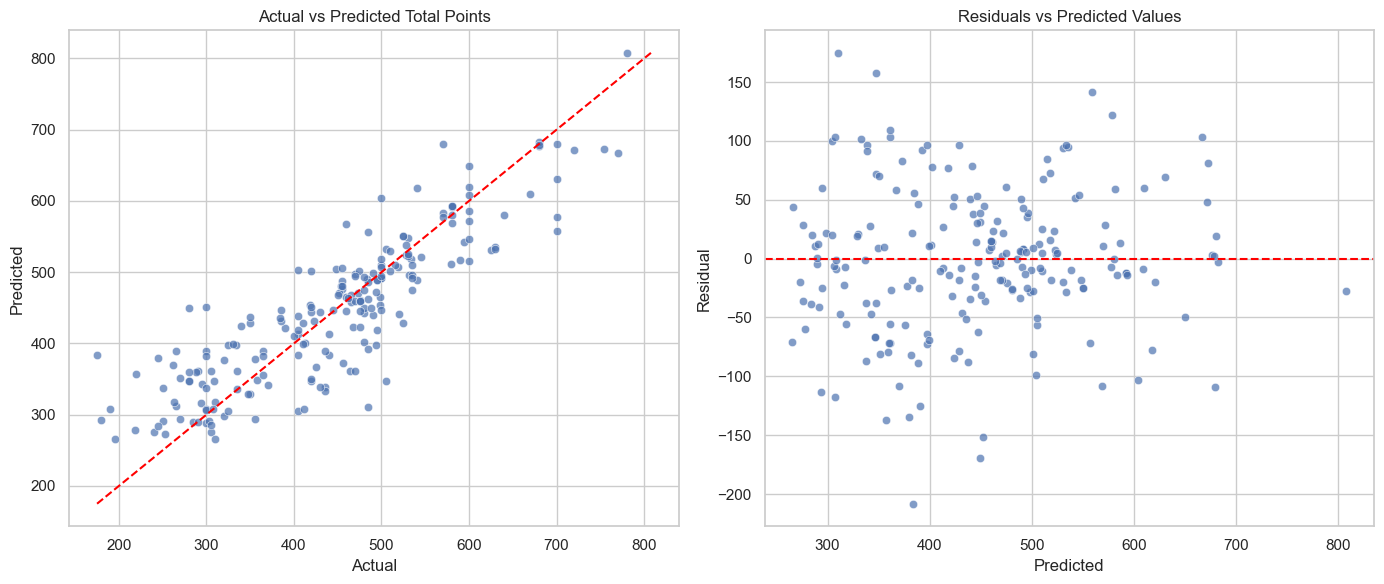

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=results, x="true_total_points", y="pred_total_points", alpha=0.7, ax=axes[0])
line_min = min(results["true_total_points"].min(), results["pred_total_points"].min())
line_max = max(results["true_total_points"].max(), results["pred_total_points"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="red")
axes[0].set_title("Actual vs Predicted Total Points")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

sns.scatterplot(data=results, x="pred_total_points", y="residual", alpha=0.7, ax=axes[1])
axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("Residuals vs Predicted Values")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

plt.tight_layout()

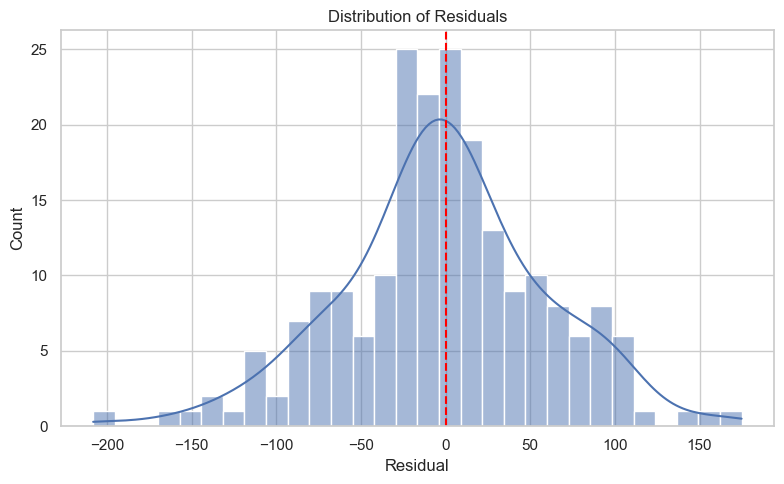

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(results["residual"], bins=30, kde=True)
plt.axvline(0, linestyle="--", color="red")
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.tight_layout()

## Worst Predictions

In [10]:
worst_predictions = results.sort_values("abs_error", ascending=False).head(20)
worst_predictions[[
    "name",
    "status",
    "type_1",
    "type_2",
    "true_total_points",
    "pred_total_points",
    "residual",
    "abs_error",
]]

,name,status,type_1,type_2,true_total_points,pred_total_points,residual,abs_error
877,Wishiwashi Solo Form,Normal,Water,NaN,175,383.235931,-208.235931,208.235931
977,Flapple,Normal,Grass,Dragon,485,310.144073,174.855927,174.855927
644,Cottonee,Normal,Grass,Fairy,280,449.225952,-169.225952,169.225952
962,Orbeetle,Normal,Bug,Psychic,505,347.299408,157.700592,157.700592
944,Meltan,Mythical,Steel,NaN,300,451.759247,-151.759247,151.759247
451,Mega Metagross,Normal,Steel,Psychic,700,558.497925,141.502075,141.502075
526,Happiny,Normal,Normal,NaN,220,356.875305,-136.875305,136.875305
54,Zubat,Normal,Poison,Flying,245,379.416382,-134.416382,134.416382
210,Ledyba,Normal,Bug,Flying,265,390.027863,-125.027863,125.027863
447,Mega Salamence,Normal,Dragon,Flying,700,578.036987,121.963013,121.963013


## Grouped Error Analysis

In [11]:
status_error_summary = (
    results.groupby("status")["abs_error"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
status_error_summary

,count,mean,median
status,,,
Mythical,4,48.547752,16.771576
Normal,184,46.343985,33.628296
Legendary,10,44.153937,38.060974
Sub Legendary,11,35.073170,13.501343


In [12]:
type_error_summary = (
    results.groupby("type_1")["abs_error"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
type_error_summary.head(10)

,count,mean,median
type_1,,,
Steel,8,78.101387,71.003265
Poison,8,55.675037,53.483658
Electric,6,55.202967,50.633759
Bug,15,54.538265,51.346252
Grass,28,54.368683,36.525299
Rock,9,49.685103,66.791595
Dragon,6,49.674550,29.697845
Normal,29,45.872658,37.555542
Ghost,10,44.212646,32.348053


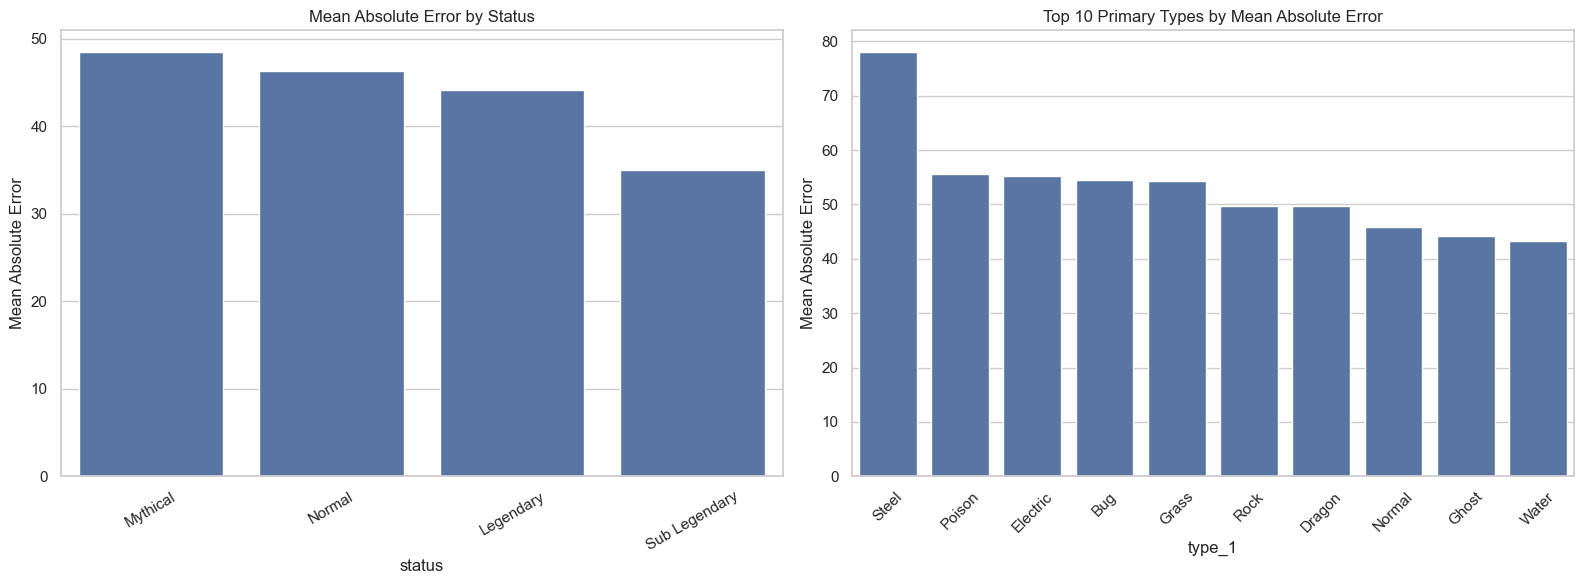

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_plot = status_error_summary.reset_index()
sns.barplot(data=status_plot, x="status", y="mean", ax=axes[0])
axes[0].set_title("Mean Absolute Error by Status")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Mean Absolute Error")

top_types = type_error_summary.head(10).reset_index()
sns.barplot(data=top_types, x="type_1", y="mean", ax=axes[1])
axes[1].set_title("Top 10 Primary Types by Mean Absolute Error")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Mean Absolute Error")

plt.tight_layout()

## Model Importance

In [14]:
feature_importance = (
    pd.Series(model.feature_importances_, index=X_test.columns)
    .sort_values(ascending=False)
)
feature_importance.head(15)

status_normal              0.258229
log_height_m               0.137978
status_mythical            0.092555
growth_rate_slow           0.055376
status_sub legendary       0.036057
log_weight_kg              0.025198
growth_rate_medium fast    0.018996
type_1_electric            0.018619
type_2_none                0.016759
type_2_rock                0.016331
type_2_fairy               0.016045
growth_rate_fluctuating    0.015477
type_2_poison              0.015201
type_1_dark                0.014520
type_1_dragon              0.014372
dtype: float32

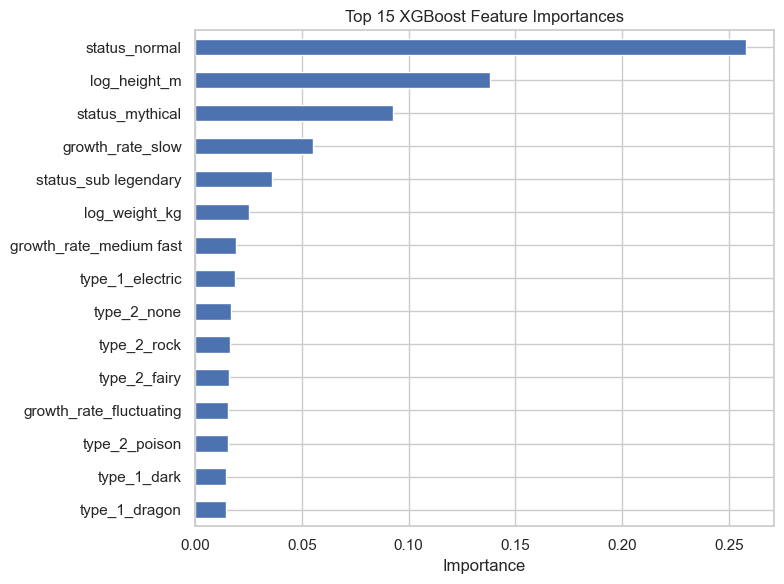

In [15]:
feature_importance.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()